# 3.5張量元素型別
    in python,value is a complate object
python這轉換動作叫做封裝
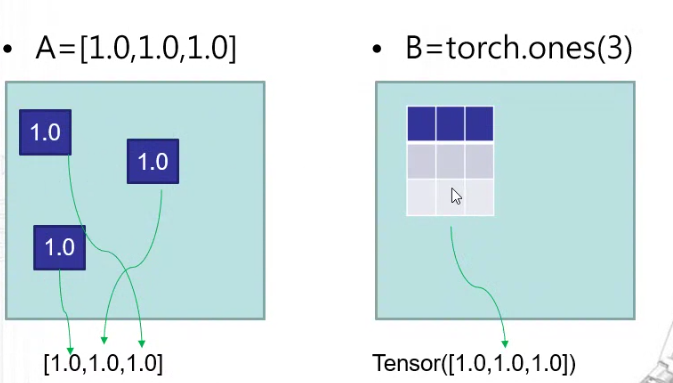


## 3.5.1 用dtype指定資料型別

In [399]:
import torch
nums1 = [1.,2.,3.]
nums2= torch.tensor(nums1)
nums1,nums2

([1.0, 2.0, 3.0], tensor([1., 2., 3.]))

In [400]:
nums1[1] = 'two'
nums2[1] = 20 #'two'
nums1,nums2

([1.0, 'two', 3.0], tensor([ 1., 20.,  3.]))

In [401]:
nums2.dtype

torch.float32

In [402]:
#nums3 = nums2.to(torch.float16)
nums3 = nums2.half()
nums3,nums3.dtype

(tensor([ 1., 20.,  3.], dtype=torch.float16), torch.float16)

In [403]:
nums4 = nums2.double()
nums4,nums4.dtype

(tensor([ 1., 20.,  3.], dtype=torch.float64), torch.float64)

In [404]:
nums5 = [128,129,130]
nums6 = torch.tensor(nums5)
nums5,nums6

([128, 129, 130], tensor([128, 129, 130]))

In [405]:
nums7 = nums6.to(torch.int8)
nums7

tensor([-128, -127, -126], dtype=torch.int8)

## 3.5.2常用dtype型別
神經網路通常使用float32
有趣的是float16在CPU不支援GPU支援
所以可以使用半精度浮點數減少資源占用量且對準確度影響不大

## 3.5.3管理張量的dtype屬性


In [406]:
nums6,nums7

(tensor([128, 129, 130]), tensor([-128, -127, -126], dtype=torch.int8))

In [407]:
nums6+nums7

tensor([0, 2, 4])

In [408]:
nums6.dtype,(nums6+nums7).dtype

(torch.int64, torch.int64)

## 3.6 其他常用張量功能


In [409]:
a = torch.ones(3,2)
a_t = torch.transpose(a,0,1)
print(a)
print(a_t)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


## 3.7 張量儲存原理
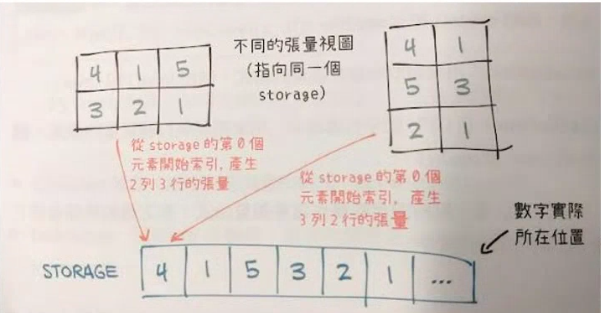

In [410]:
points = torch.tensor([[4.,1.],[5.,3.],[2.,1.]])
points.storage()

 4.0
 1.0
 5.0
 3.0
 2.0
 1.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

In [411]:
points.storage()[0] = 40.
points

tensor([[40.,  1.],
        [ 5.,  3.],
        [ 2.,  1.]])

In [412]:
points.storage()

 40.0
 1.0
 5.0
 3.0
 2.0
 1.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

In [413]:
b = torch.ones(3,2)
b.zero_()

tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])

# 3.8 大小偏移跟步長
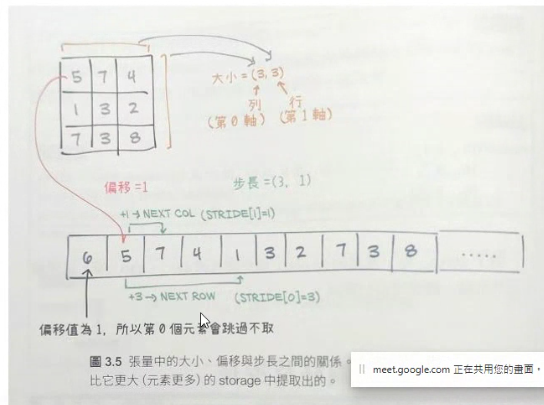

In [414]:
second_point = points[1]
second_point.storage(),points[1]

( 40.0
  1.0
  5.0
  3.0
  2.0
  1.0
 [torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6],
 tensor([5., 3.]))

In [415]:
second_point.storage_offset()

2

In [416]:
second_point.size()

torch.Size([2])

In [417]:
second_point.stride()

(1,)

In [418]:
second_point = points[1].clone()
second_point.storage(),points.storage()

( 5.0
  3.0
 [torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 2],
  40.0
  1.0
  5.0
  3.0
  2.0
  1.0
 [torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6])

In [419]:
second_point[0] = 5.
points.storage(),second_point.storage()

( 40.0
  1.0
  5.0
  3.0
  2.0
  1.0
 [torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6],
  5.0
  3.0
 [torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 2])

## 3.8.2張量轉置
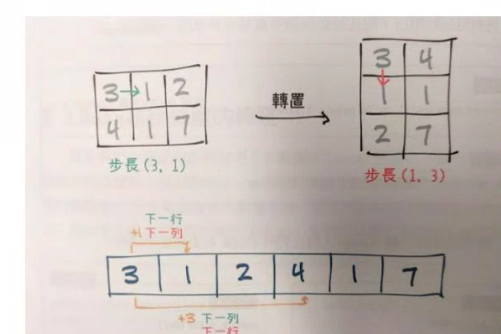


In [420]:
points_t = points.t()
points_t

tensor([[40.,  5.,  2.],
        [ 1.,  3.,  1.]])

In [421]:
points.stride(),points_t.stride()

((2, 1), (1, 2))

In [422]:
id(points.storage()) == id(points_t.storage())

False